In [0]:
print("Files in 1M dataset:")
display(dbutils.fs.ls('/databricks-datasets/cs110x/ml-1m/data-001/'))

print("Files in 20M dataset:")
display(dbutils.fs.ls('/databricks-datasets/cs110x/ml-20m/data-001/'))

Files in 1M dataset:


path,name,size,modificationTime
dbfs:/databricks-datasets/cs110x/ml-1m/data-001/README,README,5577,1596560265000
dbfs:/databricks-datasets/cs110x/ml-1m/data-001/movies.dat,movies.dat,171308,1596560265000
dbfs:/databricks-datasets/cs110x/ml-1m/data-001/movies.dat.gz,movies.dat.gz,58049,1596560265000
dbfs:/databricks-datasets/cs110x/ml-1m/data-001/ratings.dat,ratings.dat,24594131,1596560265000
dbfs:/databricks-datasets/cs110x/ml-1m/data-001/ratings.dat.gz,ratings.dat.gz,5816216,1596560265000
dbfs:/databricks-datasets/cs110x/ml-1m/data-001/users.dat,users.dat,134368,1596560265000
dbfs:/databricks-datasets/cs110x/ml-1m/data-001/users.dat.gz,users.dat.gz,40690,1596560265000


Files in 20M dataset:


path,name,size,modificationTime
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/README.txt,README.txt,8964,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/links.csv,links.csv,569517,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/links.csv.gz,links.csv.gz,245973,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/movies.csv,movies.csv,1397542,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/movies.csv.gz,movies.csv.gz,498839,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/ratings.csv,ratings.csv,533444411,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/ratings.csv.gz,ratings.csv.gz,132656084,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/tags.csv,tags.csv,16603996,1596560266000
dbfs:/databricks-datasets/cs110x/ml-20m/data-001/tags.csv.gz,tags.csv.gz,4787917,1596560267000


In [0]:
print("Preview of 20M ratings.csv (first 5 lines):")
ratings_preview = dbutils.fs.head("/databricks-datasets/cs110x/ml-20m/data-001/ratings.csv", 500)
print(ratings_preview)


# Preview of movies file
print("Preview of 20M movies.csv (first 5 lines):")
movies_preview = dbutils.fs.head("/databricks-datasets/cs110x/ml-20m/data-001/movies.csv", 500)
print(movies_preview)

Preview of 20M ratings.csv (first 5 lines):
[Truncated to first 500 bytes]
userId,movieId,rating,timestamp
1,2,3.5,1112486027
1,29,3.5,1112484676
1,32,3.5,1112484819
1,47,3.5,1112484727
1,50,3.5,1112484580
1,112,3.5,1094785740
1,151,4.0,1094785734
1,223,4.0,1112485573
1,253,4.0,1112484940
1,260,4.0,1112484826
1,293,4.0,1112484703
1,296,4.0,1112484767
1,318,4.0,1112484798
1,337,3.5,1094785709
1,367,3.5,1112485980
1,541,4.0,1112484603
1,589,3.5,1112485557
1,593,3.5,1112484661
1,653,3.0,1094785691
1,919,3.5,1094785621
1,924,3.5,1094785598
1,1009,3.5,
Preview of 20M movies.csv (first 5 lines):
[Truncated to first 500 bytes]
movieId,title,genres
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,Jumanji (1995),Adventure|Children|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama|Romance
5,Father of the Bride Part II (1995),Comedy
6,Heat (1995),Action|Crime|Thriller
7,Sabrina (1995),Comedy|Romance
8,Tom and Huck (1995),Adventure|Children
9,

In [0]:
from pyspark.sql.types import *

movies_schema = StructType([
    StructField('movieId', IntegerType()),
    StructField('title', StringType()),
    StructField('genres', StringType())
])

ratings_schema = StructType([
    StructField('userId', IntegerType()),
    StructField('movieId', IntegerType()),
    StructField('rating', FloatType()),
    StructField('timestamp', IntegerType())  # We add this because 20M has it
])

print("Schemas defined successfully!")

Schemas defined successfully!


In [0]:
file_location = "/databricks-datasets/cs110x/ml-20m/data-001/movies.csv"
file_type = "csv"

infer_schema = "false"  
first_row_is_header = "true"  
delimiter = ","  

df_movies = spark.read.format(file_type) \
    .option("inferSchema", infer_schema) \
    .option("header", first_row_is_header) \
    .option("sep", delimiter) \
    .schema(movies_schema) \
    .load(file_location)

print(f"Total movies loaded: {df_movies.count()}")
display(df_movies)

Total movies loaded: 27278


movieId,title,genres
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,Jumanji (1995),Adventure|Children|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama|Romance
5,Father of the Bride Part II (1995),Comedy
6,Heat (1995),Action|Crime|Thriller
7,Sabrina (1995),Comedy|Romance
8,Tom and Huck (1995),Adventure|Children
9,Sudden Death (1995),Action
10,GoldenEye (1995),Action|Adventure|Thriller


In [0]:
file_location = "/databricks-datasets/cs110x/ml-20m/data-001/ratings.csv"
file_type = "csv"

infer_schema = "false"
first_row_is_header = "true"  # 20M has headers
delimiter = ","  # 20M uses commas

df_ratings = spark.read.format(file_type) \
    .option("inferSchema", infer_schema) \
    .option("header", first_row_is_header) \
    .option("sep", delimiter) \
    .schema(ratings_schema) \
    .load(file_location)

print(f"Total ratings loaded: {df_ratings.count()}")
display(df_ratings)

Total ratings loaded: 20000263


userId,movieId,rating,timestamp
1,2,3.5,1112486027
1,29,3.5,1112484676
1,32,3.5,1112484819
1,47,3.5,1112484727
1,50,3.5,1112484580
1,112,3.5,1094785740
1,151,4.0,1094785734
1,223,4.0,1112485573
1,253,4.0,1112484940
1,260,4.0,1112484826


In [0]:
df_ratings = df_ratings.drop('timestamp')

print("Statistics for the 'rating' column:")
df_ratings.select('rating').describe().show()

Statistics for the 'rating' column:
+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|          20000263|
|   mean|3.5255285642993797|
| stddev|1.0519889192942418|
|    min|               0.5|
|    max|               5.0|
+-------+------------------+



In [0]:
df_ratings_train, df_ratings_test = df_ratings.randomSplit([0.8, 0.2], seed=42)

print(f"Training set size: {df_ratings_train.count():,} ratings")
print(f"Testing set size: {df_ratings_test.count():,} ratings")

Training set size: 15,999,973 ratings
Testing set size: 4,000,290 ratings


In [0]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd


ranks = [5, 10, 15]  
max_iters = [5, 10, 15]  
reg_params = [0.01, 0.1, 0.5]  

results = []

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

print("Starting parameter testing... This will take a while!\n")

test_number = 0
total_tests = len(ranks) * len(max_iters) * len(reg_params)

for rank in ranks:
    for max_iter in max_iters:
        for reg_param in reg_params:
            test_number += 1
            
            print(f"Test {test_number}/{total_tests}: rank={rank}, maxIter={max_iter}, regParam={reg_param}")
            
            als = ALS(
                rank=rank,
                maxIter=max_iter,
                regParam=reg_param,
                userCol="userId",
                itemCol="movieId",
                ratingCol="rating",
                coldStartStrategy="drop"  
            )
            
            
            model = als.fit(df_ratings_train)
            
            predictions = model.transform(df_ratings_test)
            
            predictions = predictions.filter(predictions.prediction != float('nan'))
            
            rmse = evaluator.evaluate(predictions)
            
            print(f"  → RMSE: {rmse:.4f}")
            
            results.append({
                'rank': rank,
                'maxIter': max_iter,
                'regParam': reg_param,
                'RMSE': rmse
            })

print("All tests completed!")

results_df = pd.DataFrame(results)

results_df = results_df.sort_values('RMSE')

print("\nAll Results (sorted by RMSE):")
print(results_df.to_string(index=False))

Starting parameter testing... This will take a while!

Test 1/27: rank=5, maxIter=5, regParam=0.01
  → RMSE: 0.8237
Test 2/27: rank=5, maxIter=5, regParam=0.1
  → RMSE: 0.8168
Test 3/27: rank=5, maxIter=5, regParam=0.5
  → RMSE: 1.0259
Test 4/27: rank=5, maxIter=10, regParam=0.01
  → RMSE: 0.8143
Test 5/27: rank=5, maxIter=10, regParam=0.1
  → RMSE: 0.8147
Test 6/27: rank=5, maxIter=10, regParam=0.5
  → RMSE: 0.9979
Test 7/27: rank=5, maxIter=15, regParam=0.01
  → RMSE: 0.8118
Test 8/27: rank=5, maxIter=15, regParam=0.1
  → RMSE: 0.8140
Test 9/27: rank=5, maxIter=15, regParam=0.5
  → RMSE: 0.9970
Test 10/27: rank=10, maxIter=5, regParam=0.01
  → RMSE: 0.8112
Test 11/27: rank=10, maxIter=5, regParam=0.1
  → RMSE: 0.8209
Test 12/27: rank=10, maxIter=5, regParam=0.5
  → RMSE: 0.9996
Test 13/27: rank=10, maxIter=10, regParam=0.01
  → RMSE: 0.8037
Test 14/27: rank=10, maxIter=10, regParam=0.1
  → RMSE: 0.8096
Test 15/27: rank=10, maxIter=10, regParam=0.5
  → RMSE: 0.9970
Test 16/27: rank=10

In [0]:
import pandas as pd

best_model_params = results_df.iloc[0]

print("BEST MODEL FOUND:")
print(f"Rank: {best_model_params['rank']}")
print(f"Max Iterations: {best_model_params['maxIter']}")
print(f"Regularization Parameter: {best_model_params['regParam']}")
print(f"RMSE: {best_model_params['RMSE']:.4f}")

print("\nTop 5 Best Models:")
print(results_df.head(5).to_string(index=False))

BEST MODEL FOUND:
Rank: 10.0
Max Iterations: 15.0
Regularization Parameter: 0.01
RMSE: 0.8022

Top 5 Best Models:
 rank  maxIter  regParam     RMSE
   10       15      0.01 0.802218
   10       10      0.01 0.803729
   15       15      0.10 0.805005
   10       15      0.10 0.806763
   15       10      0.10 0.808275


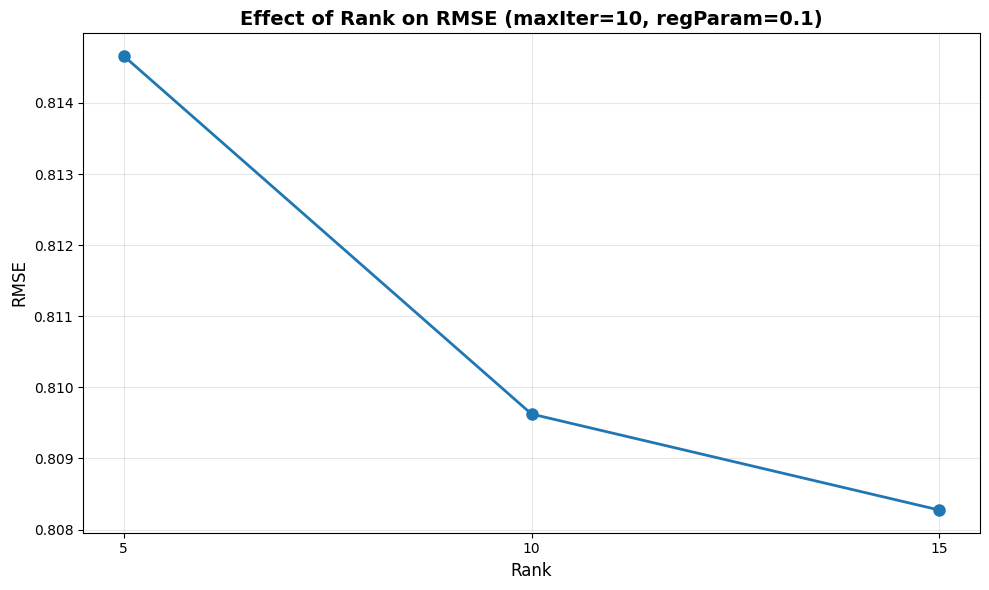

Lower RMSE is better! The optimal rank minimizes the error.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

baseline_results = results_df[(results_df['maxIter'] == 10) & (results_df['regParam'] == 0.1)]

plt.figure(figsize=(10, 6))
plt.plot(baseline_results['rank'], baseline_results['RMSE'], marker='o', linewidth=2, markersize=8)
plt.xlabel('Rank', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Effect of Rank on RMSE (maxIter=10, regParam=0.1)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(baseline_results['rank'])

plt.tight_layout()
plt.show()

print("Lower RMSE is better! The optimal rank minimizes the error.")

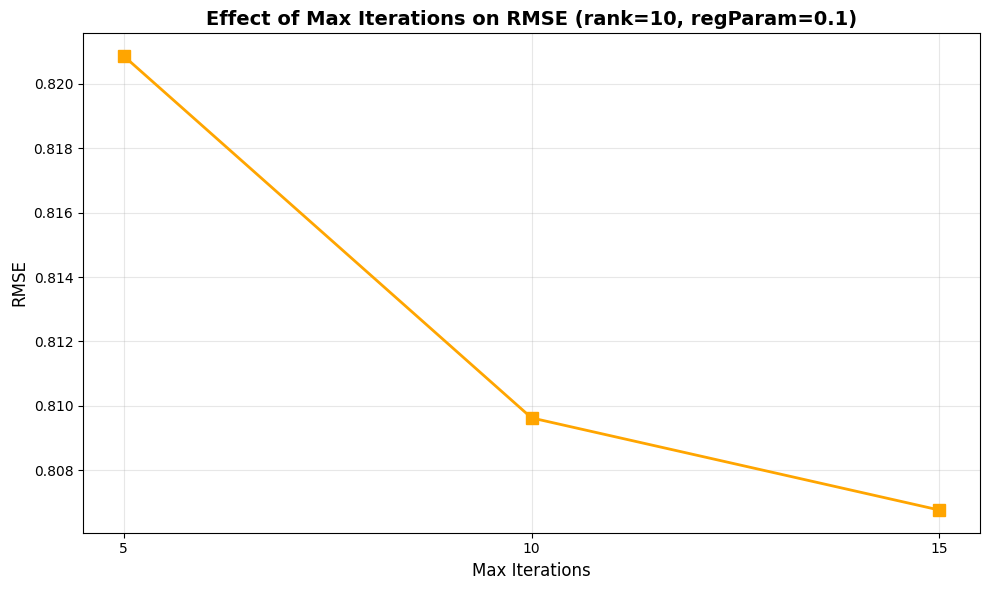

More iterations usually improve the model, but with diminishing returns.


In [0]:

baseline_results = results_df[(results_df['rank'] == 10) & (results_df['regParam'] == 0.1)]

plt.figure(figsize=(10, 6))
plt.plot(baseline_results['maxIter'], baseline_results['RMSE'], marker='s', linewidth=2, markersize=8, color='orange')
plt.xlabel('Max Iterations', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Effect of Max Iterations on RMSE (rank=10, regParam=0.1)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(baseline_results['maxIter'])

plt.tight_layout()
plt.show()

print("More iterations usually improve the model, but with diminishing returns.")

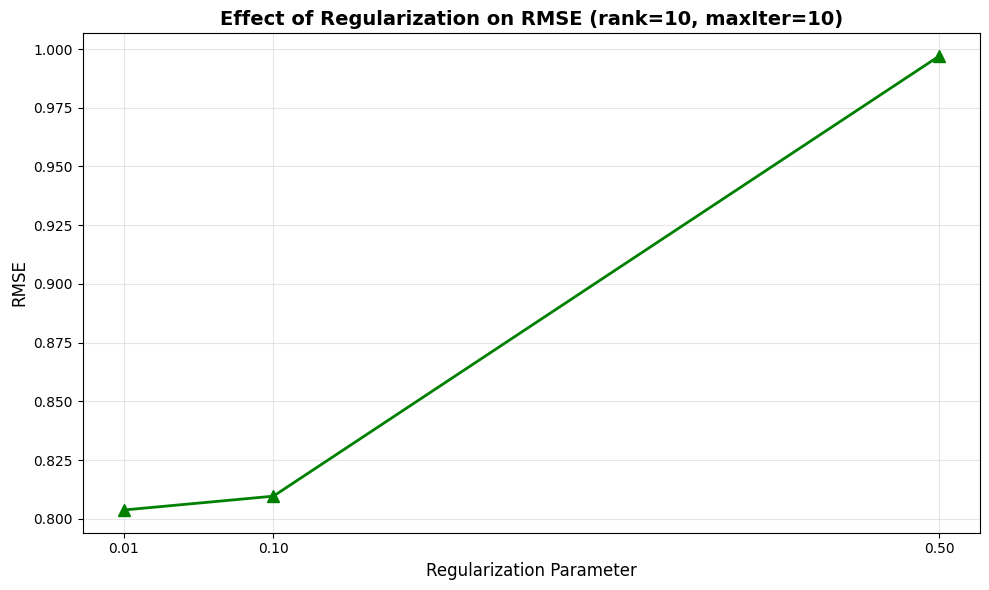

Regularization prevents overfitting. Too much can hurt performance!


In [0]:

baseline_results = results_df[(results_df['rank'] == 10) & (results_df['maxIter'] == 10)]

plt.figure(figsize=(10, 6))
plt.plot(baseline_results['regParam'], baseline_results['RMSE'], marker='^', linewidth=2, markersize=8, color='green')
plt.xlabel('Regularization Parameter', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Effect of Regularization on RMSE (rank=10, maxIter=10)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(baseline_results['regParam'])

plt.tight_layout()
plt.show()

print("Regularization prevents overfitting. Too much can hurt performance!")

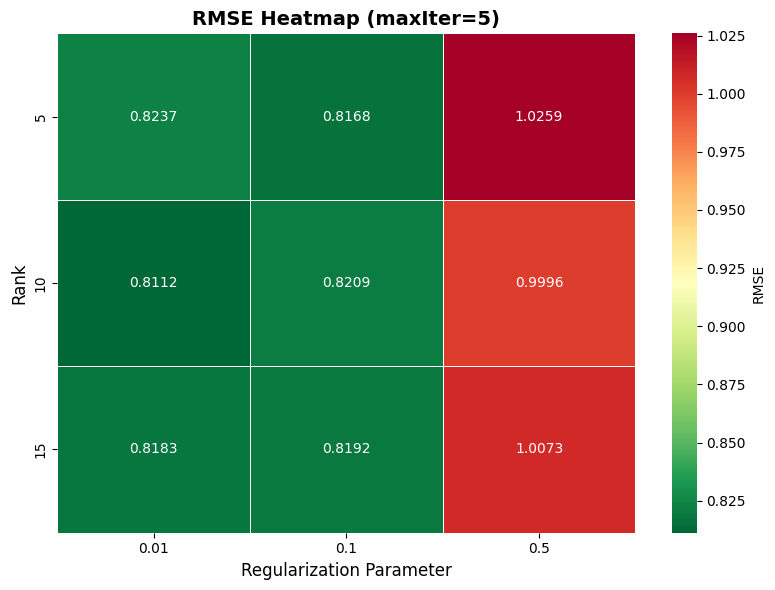

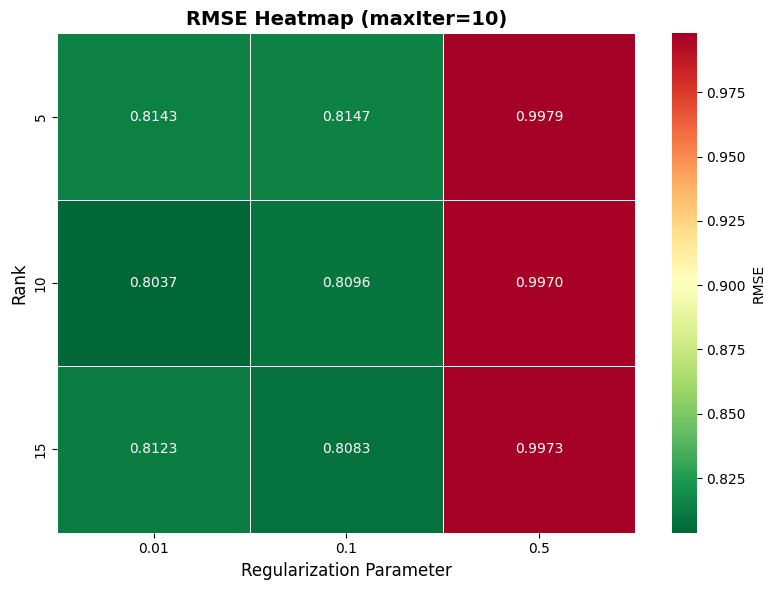

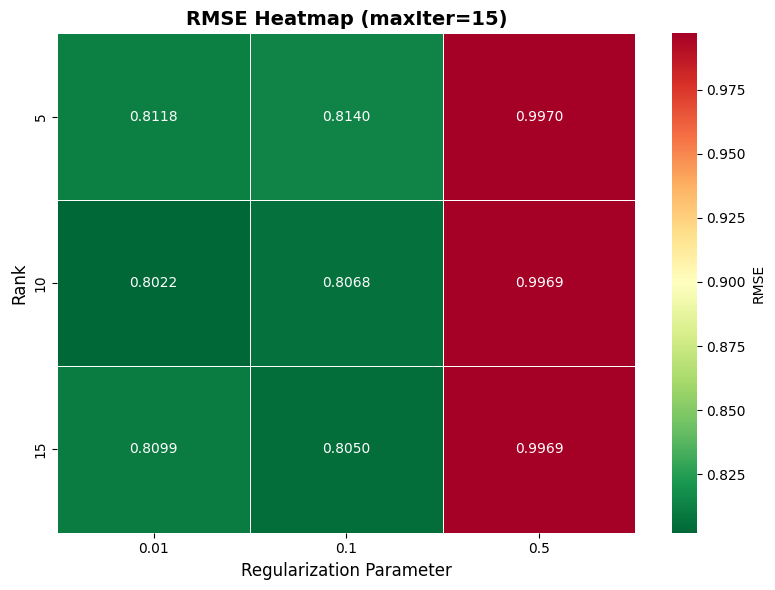

Darker green = better (lower RMSE)
Red = worse (higher RMSE)


In [0]:

import seaborn as sns

for max_iter_val in max_iters:
    subset = results_df[results_df['maxIter'] == max_iter_val]
    
    pivot_table = subset.pivot(index='rank', columns='regParam', values='RMSE')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='RdYlGn_r', 
                cbar_kws={'label': 'RMSE'}, linewidths=0.5)
    plt.title(f'RMSE Heatmap (maxIter={max_iter_val})', fontsize=14, fontweight='bold')
    plt.xlabel('Regularization Parameter', fontsize=12)
    plt.ylabel('Rank', fontsize=12)
    plt.tight_layout()
    plt.show()

print("Darker green = better (lower RMSE)")
print("Red = worse (higher RMSE)")

In [0]:
best_rank = int(best_model_params['rank'])
best_maxIter = int(best_model_params['maxIter'])
best_regParam = float(best_model_params['regParam'])

print("Training final model with BEST parameters:")
print(f"  Rank: {best_rank}")
print(f"  Max Iterations: {best_maxIter}")
print(f"  Regularization: {best_regParam}")
print("\nTraining...")

als_best = ALS(
    rank=best_rank,
    maxIter=best_maxIter,
    regParam=best_regParam,
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop"
)

best_model = als_best.fit(df_ratings_train)

print("✓ Best model trained successfully!")

Training final model with BEST parameters:
  Rank: 10
  Max Iterations: 15
  Regularization: 0.01

Training...
✓ Best model trained successfully!


In [0]:
print("Here are some popular movies you can rate:")
print("(Search for movies you've seen in the movies dataset)")

example_movies = df_movies.filter(
    (df_movies.title.contains("Matrix")) |
    (df_movies.title.contains("Star Wars")) |
    (df_movies.title.contains("Godfather")) |
    (df_movies.title.contains("Avengers")) |
    (df_movies.title.contains("Inception"))
).select("movieId", "title", "genres")

display(example_movies)

Here are some popular movies you can rate:
(Search for movies you've seen in the movies dataset)


movieId,title,genres
260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
858,"Godfather, The (1972)",Crime|Drama
1196,Star Wars: Episode V - The Empire Strikes Back (1980),Action|Adventure|Sci-Fi
1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
1221,"Godfather: Part II, The (1974)",Crime|Drama
2023,"Godfather: Part III, The (1990)",Crime|Drama|Mystery|Thriller
2153,"Avengers, The (1998)",Action|Adventure
2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi
5378,Star Wars: Episode II - Attack of the Clones (2002),Action|Adventure|Sci-Fi|IMAX


In [0]:

from pyspark.sql.functions import lit
def search_movies(keyword):
    """Search for movies by title"""
    results = df_movies.filter(df_movies.title.contains(keyword)) \
                       .select("movieId", "title", "genres")
    return results

search_keywords = [
    "Avengers",
    "Harry Potter",
    "Lord of the Rings",
    "Inception",
    "Dark Knight",
    "Titanic",
    "Matrix",
    "Interstellar",
    "Frozen",
    "Toy Story",
    "Spider-Man",
    "Iron Man",
    "Star Wars",
    "Jurassic"
]

print("Searching for popular movies...")

all_results = None

for keyword in search_keywords:
    results = search_movies(keyword)
    
    if all_results is None:
        all_results = results
    else:
        all_results = all_results.union(results)

all_results = all_results.dropDuplicates(["movieId"])

all_results = all_results.orderBy("title")

print(f"\nFound {all_results.count()} movies total")
print("Browse this table to find movieId for movies you want to rate:")

display(all_results)

Searching for popular movies...

Found 84 movies total
Browse this table to find movieId for movies you want to rate:


movieId,title,genres
95510,"Amazing Spider-Man, The (2012)",Action|Adventure|Sci-Fi|IMAX
110132,Avengers Confidential: Black Widow & Punisher (2014),Action|Animation|Sci-Fi
2153,"Avengers, The (1998)",Action|Adventure
89745,"Avengers, The (2012)",Action|Adventure|Sci-Fi|IMAX
103454,Batman Unmasked: The Psychology of the Dark Knight (2008),Documentary
98124,"Batman: The Dark Knight Returns, Part 1 (2012)",Action|Animation|Sci-Fi
99813,"Batman: The Dark Knight Returns, Part 2 (2013)",Action|Animation
2157,"Chambermaid on the Titanic, The (Femme de chambre du Titanic, La) (1998)",Romance
115727,Crippled Avengers (Can que) (Return of the 5 Deadly Venoms) (1981),Action|Adventure
91529,"Dark Knight Rises, The (2012)",Action|Adventure|Crime|IMAX


In [0]:
my_user_id = 999999  


my_rated_movies = [
    # The Avengers
    (my_user_id, 89745, 4.5),    # Avengers, The (2012) - CHANGE RATING
    
    # Harry Potter Series
    (my_user_id, 4896, 4.0),     # Harry Potter and the Sorcerer's Stone (2001) - CHANGE RATING
    (my_user_id, 5816, 4.0),     # Harry Potter and the Chamber of Secrets (2002) - CHANGE RATING
    
    # The Dark Knight Trilogy
    (my_user_id, 58559, 5.0),    # Dark Knight, The (2008) - CHANGE RATING
    (my_user_id, 91529, 4.5),    # Dark Knight Rises, The (2012) - CHANGE RATING
    
    # Toy Story
    (my_user_id, 1, 4.5),        # Toy Story (1995) - CHANGE RATING
    (my_user_id, 3114, 4.0),     # Toy Story 2 (1999) - CHANGE RATING
    
    # Inception
    (my_user_id, 79132, 5.0),    # Inception (2010) - CHANGE RATING
    
    # Frozen
    (my_user_id, 106696, 3.5),   # Frozen (2013) - CHANGE RATING
    
    # Jurassic Park
    (my_user_id, 480, 4.0),      # Jurassic Park (1993) - CHANGE RATING
    
    # The Matrix
    (my_user_id, 2571, 4.5),     # Matrix, The (1999) - CHANGE RATING
    
    # Titanic
    (my_user_id, 1721, 3.5),     # Titanic (1997) - CHANGE RATING
    
    # Iron Man
    (my_user_id, 59315, 4.0),    # Iron Man (2008) - CHANGE RATING
    (my_user_id, 77561, 3.5),    # Iron Man 2 (2010) - CHANGE RATING
]

df_my_ratings = spark.createDataFrame(my_rated_movies, ["userId", "movieId", "rating"])

print(f"✓ You have rated {df_my_ratings.count()} movies:")
display(df_my_ratings.join(df_movies, on="movieId").select("title", "genres", "rating"))

✓ You have rated 14 movies:


title,genres,rating
Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,4.5
Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,4.0
Titanic (1997),Drama|Romance,3.5
"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.5
Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,4.0
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001),Adventure|Children|Fantasy,4.0
Harry Potter and the Chamber of Secrets (2002),Adventure|Fantasy,4.0
"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,5.0
Iron Man (2008),Action|Adventure|Sci-Fi,4.0
Iron Man 2 (2010),Action|Adventure|Sci-Fi|Thriller|IMAX,3.5


In [0]:
df_all_ratings = df_ratings_train.union(df_my_ratings)

print(f"Original training data: {df_ratings_train.count():,} ratings")
print(f"Your ratings: {df_my_ratings.count()} ratings")
print(f"Combined data: {df_all_ratings.count():,} ratings")

Original training data: 15,999,973 ratings
Your ratings: 14 ratings
Combined data: 15,999,987 ratings


In [0]:
print("Training personalized model with YOUR ratings...")
print(f"Using best parameters: rank={best_rank}, maxIter={best_maxIter}, regParam={best_regParam}")

als_personalized = ALS(
    rank=best_rank,
    maxIter=best_maxIter,
    regParam=best_regParam,
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop"
)

# Train the model with your ratings included
personalized_model = als_personalized.fit(df_all_ratings)

print("✓ Personalized model trained!")

Training personalized model with YOUR ratings...
Using best parameters: rank=10, maxIter=15, regParam=0.01
✓ Personalized model trained!


In [0]:

from pyspark.sql.functions import lit, col, desc

print("Generating recommendations for YOU...\n")

print("Checking column names...")
print(f"df_movies columns: {df_movies.columns}")
print(f"df_my_ratings columns: {df_my_ratings.columns}")
print()

df_movies_unrated = df_movies.join(
    df_my_ratings.select("movieId"),  # Only need movieId for the join
    on="movieId",
    how="left_anti"  # Only movies NOT in your ratings
)

print(f"Movies you haven't rated: {df_movies_unrated.count():,}")

df_for_prediction = df_movies_unrated.withColumn("userId", lit(my_user_id))

print("Making predictions... (this may take a minute)")
df_predictions = personalized_model.transform(df_for_prediction)

df_recommendations = df_predictions.filter(df_predictions.prediction != float('nan')) \
                                   .orderBy(desc("prediction"))

print("YOUR TOP 20 PERSONALIZED MOVIE RECOMMENDATIONS:")

top_20 = df_recommendations.select("title", "genres", "prediction").limit(20)
display(top_20)

print("FORMATTED TOP 20 RECOMMENDATIONS:")

top_20_pandas = top_20.toPandas()
for idx, row in top_20_pandas.iterrows():
    print(f"\n{idx+1:2d}. {row['title']}")
    print(f"    Genres: {row['genres']}")
    print(f"    Predicted Rating: {row['prediction']:.2f} ⭐")

print("🎬 Happy watching! These are movies the AI thinks you'll love!")

Generating recommendations for YOU...

Checking column names...
df_movies columns: ['movieId', 'title', 'genres']
df_my_ratings columns: ['userId', 'movieId', 'rating']

Movies you haven't rated: 27,264
Making predictions... (this may take a minute)
YOUR TOP 20 PERSONALIZED MOVIE RECOMMENDATIONS:


title,genres,prediction
Diary of a Lost Girl (Tagebuch einer Verlorenen) (1929),Drama,11.27469
Esa ja Vesa - auringonlaskun ratsastajat (1994),Action|Adventure|Comedy|Crime,9.187775
Rewind This! (2013),Documentary,9.046684
"Pretty Village, Pretty Flame (Lepa sela lepo gore) (1996)",Drama|War,8.792366
"Speed Of Thought, The (2011)",Sci-Fi|Thriller,8.3906
Babes on Broadway (1941),Comedy|Musical|Romance,8.341292
"Marriage Made in Heaven, A (Rab Ne Bana Di Jodi) (2008)",Comedy|Drama|Musical|Romance,8.33323
"Lost Thing, The (2010)",Animation|Drama|Fantasy,8.137206
Cool It (2010),Documentary,8.127852
National Theatre Live: Frankenstein,Drama|Fantasy,8.097046


FORMATTED TOP 20 RECOMMENDATIONS:

 1. Diary of a Lost Girl (Tagebuch einer Verlorenen) (1929)
    Genres: Drama
    Predicted Rating: 11.27 ⭐

 2. Esa ja Vesa - auringonlaskun ratsastajat (1994)
    Genres: Action|Adventure|Comedy|Crime
    Predicted Rating: 9.19 ⭐

 3. Rewind This! (2013)
    Genres: Documentary
    Predicted Rating: 9.05 ⭐

 4. Pretty Village, Pretty Flame (Lepa sela lepo gore) (1996)
    Genres: Drama|War
    Predicted Rating: 8.79 ⭐

 5. Speed Of Thought, The (2011)
    Genres: Sci-Fi|Thriller
    Predicted Rating: 8.39 ⭐

 6. Babes on Broadway (1941)
    Genres: Comedy|Musical|Romance
    Predicted Rating: 8.34 ⭐

 7. Marriage Made in Heaven, A (Rab Ne Bana Di Jodi) (2008)
    Genres: Comedy|Drama|Musical|Romance
    Predicted Rating: 8.33 ⭐

 8. Lost Thing, The (2010)
    Genres: Animation|Drama|Fantasy
    Predicted Rating: 8.14 ⭐

 9. Cool It (2010)
    Genres: Documentary
    Predicted Rating: 8.13 ⭐

10. National Theatre Live: Frankenstein
    Genres: Drama|

In [0]:

print("PROJECT SUMMARY")
print(f"\nDataset: 20 Million Movie Ratings")
print(f"Total movies: {df_movies.count():,}")
print(f"Total ratings: {df_ratings.count():,}")
print(f"\nBest Model Parameters:")
print(f"  - Rank: {best_rank}")
print(f"  - Max Iterations: {best_maxIter}")
print(f"  - Regularization: {best_regParam}")
print(f"  - RMSE: {best_model_params['RMSE']:.4f}")
print(f"\nYour Ratings: {df_my_ratings.count()}")
print(f"Recommendations Generated: 20")

PROJECT SUMMARY

Dataset: 20 Million Movie Ratings
Total movies: 27,278
Total ratings: 20,000,263

Best Model Parameters:
  - Rank: 10
  - Max Iterations: 15
  - Regularization: 0.01
  - RMSE: 0.8022

Your Ratings: 14
Recommendations Generated: 20
